Audio Engineering Basics

1. Load audio & Inspect - Basics

In [1]:
from pydub import AudioSegment

In [4]:
audio=AudioSegment.from_file("input_mp3files/rapbeatsong.mp3")

In [5]:
print("Duration (sec):", audio.duration_seconds)
print("Channels:", audio.channels)
print("Frame Rate:", audio.frame_rate)
print("Sample Width (bytes):", audio.sample_width)
print("dBFS (average loudness):", audio.dBFS)

Duration (sec): 249.70739229024943
Channels: 2
Frame Rate: 44100
Sample Width (bytes): 2
dBFS (average loudness): -9.198374198176392


2.Slicing Audio(Show output sizes)

In [6]:
first_5_sec=audio[:5000]
next_5_sec=audio[5000:10000]
print(next_5_sec)

3. Fade In / Fade Out Demo

In [7]:
fade_out_clip=audio[:5000].fade_out(3000) # Begin to reduce sound at the start of 3rd sec of the song
fade_in_clip=audio[:5000].fade_in(3000) # start low and at 3rd sec will rise up sound



# Join 2 clips

In [8]:
fade_out_clip+fade_in_clip

Simple wave form plot using Librosa(beat matching) and Matplotlib

- Peaks=Loud part of the music
- Valleys=quiet part of the music
- They visually understands fade slicing transitions

In [9]:
import librosa
from librosa import display
import matplotlib
from matplotlib import pyplot as plt

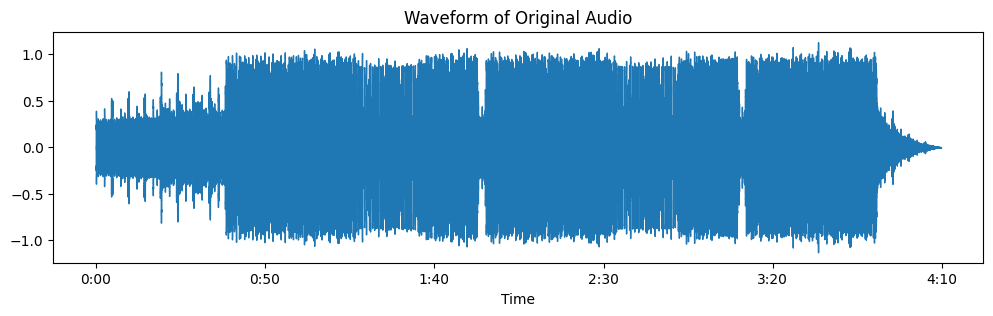

In [14]:
# sr  - sampling rate 

y,sr=librosa.load("input_mp3files/rapbeatsong.mp3",sr=None)

plt.figure(figsize=(12,3))
librosa.display.waveshow(y,sr=sr)
plt.title("Waveform of Original Audio")
plt.show()



Visualize fade-in fade-out

<function matplotlib.pyplot.show(close=None, block=None)>

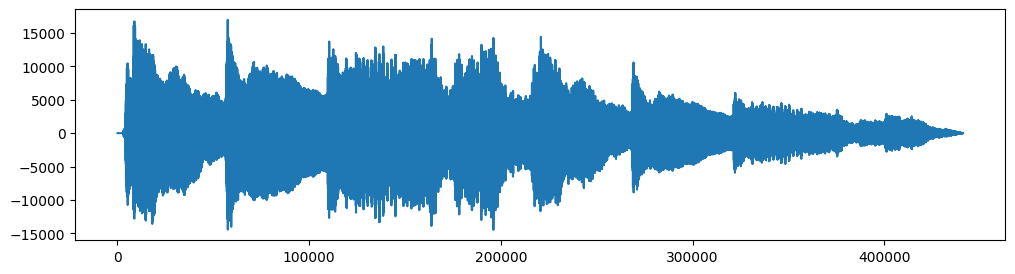

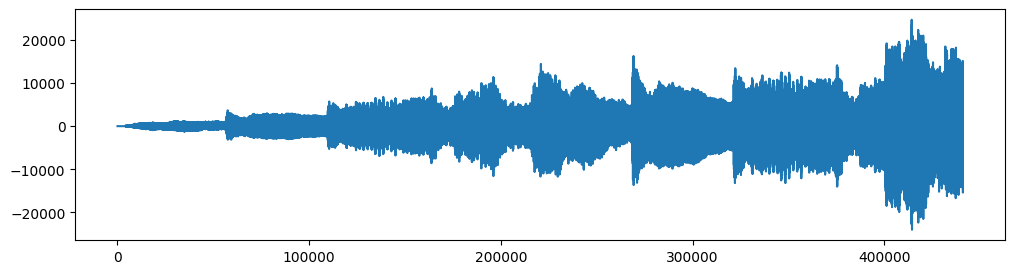

In [15]:
fade_in_audio=fade_in_clip.get_array_of_samples()
fade_out_audio=fade_out_clip.get_array_of_samples()

plt.figure(figsize=(12,3))
plt.plot(fade_out_audio)
plt.show


plt.figure(figsize=(12,3))
plt.plot(fade_in_audio)
plt.show


Core Logic

In [16]:
from pydub import AudioSegment
import os, random

#### Mix tape audio(mp3) generator

A function that search for audio files and define fadeout for first song and fadein for the next song  and mix the songs with overlap . so that we get songs all mix together along with their fadein's and fadeout's 

In [39]:
def smooth_fade_mixtape(track_folder:str, output="output/mixtape.mp3", transition_ms=6000):

    files=[files for files in os.listdir(track_folder) if files.endswith((".mp3",".wav"))]
    files.sort()

    mixtape=None  # Initial variable to store first song as a start
    for file in files:
        song=AudioSegment.from_file(os.path.join(track_folder,file))
        song = song.set_channels(2).set_frame_rate(44100)  # stereo

        if mixtape is None:
            mixtape=song  # Storing first song

        else: # Condition alwyas start with 2nd song as first song store in 'mixtape' variable

            # Define overlap region , just in case if any song less duration than transition time(6sec)
            overlap=min(transition_ms,len(song),len(mixtape)) # output= 6000
            
            # Outgoing: fadeout + high pass to remove bass 
            # -overlap: =-6000: last 6 sec of the song in the song index
            outgoing=mixtape[-overlap:].fade_out(overlap).low_pass_filter(4000)

            # incoming: fade in + low-pass to smooth highs
            incoming=song[:overlap].fade_in(overlap).low_pass_filter(4000)


            # overlay transition
            transition=outgoing.overlay(incoming)

            mixtape=mixtape[:-overlap]+transition+song[overlap:]

    return mixtape.export(output,format="mp3")
    # print(f"✅ Smooth fade mixtape generated: {output}")

smooth_fade_mixtape("input_mp3files")


<_io.BufferedRandom name='output/mixtape.mp3'>

#### Description Generator

In [44]:
import os
from pydub import AudioSegment

def generate_youtube_description_with_timestamps(track_folder,mixtape_name="Pryn House Mixtape", genre="Pryn House", start_time_sec=0):
    """
    Generate a youtube description with tracklist, timestamps, and hashtags,
    Assumes audio files are in order of playback
    """

    audio_extensions=(".mp3", ".wav", ".flac", ".aac", ".ogg", ".m4a")
    tracks=[file for file in os.listdir(track_folder) if file.lower().endswith(audio_extensions)]

    if not tracks:
        return "No audio tracks found in the folder!"

    tracks.sort() # align mix tape generation code.. so that tracks are following alphabetical order during mixtape creation and also now to genereate description

    description = f"🔥 {mixtape_name} 🔥\n"
    description += f"Genre: {genre}\n\n"
    description += "🎵 Tracklist:\n"

    current_time = start_time_sec

    for track in tracks:
        track_path=os.path.join(track_folder,track)
        song=AudioSegment.from_file(track_path)
        duration_sec=int(song.duration_seconds)  # Duration in sec (len(song)//1000 -alternative)


        # Format timestamp mm:ss

        minutes=current_time//60
        seconds=current_time % 60
        timestamp=f"{minutes:02d}:{seconds:02d}"

        track_name = os.path.splitext(track)[0]
        description += f"{timestamp} - {track_name}\n"

        current_time += duration_sec  # increment for next track

    description += "\n💽 Download/Listen links:\n"
    description += "You can find these tracks online or on Spotify/Apple Music.\n\n"
    description += "🎧 Follow for more Pryn House mixes!\n\n"

    hashtags = [
        "#AfroHouse", "#HouseMusic", "#EDM", "#DanceMusic", "#Mixtape",
        "#ElectronicMusic", "#DJMix", "#PartyMusic", "#DeepHouse", "#AfroHouseVibes"
    ]

    description += " ".join(hashtags)

    return print(description)

track_folder = r"input_mp3files"

generate_youtube_description_with_timestamps(track_folder)

        





🔥 Pryn House Mixtape 🔥
Genre: Pryn House

🎵 Tracklist:
00:00 - AwenCaiiro  Your Voice Adam Port Remix MIDH 043
04:20 - WavesWavs
09:48 - rapbeatsong

💽 Download/Listen links:
You can find these tracks online or on Spotify/Apple Music.

🎧 Follow for more Pryn House mixes!

#AfroHouse #HouseMusic #EDM #DanceMusic #Mixtape #ElectronicMusic #DJMix #PartyMusic #DeepHouse #AfroHouseVibes


#### VIDEO GENERATOR

The function takes an image and an audio file, resizes the image to a fixed video resolution, and saves it temporarily. It then builds an FFmpeg command that loops the image, combines it with the audio, and encodes the result using H.264 video and AAC audio. A very low FPS and the ultrafast preset are used to make rendering extremely fast, since the visual is static. FFmpeg creates an MP4 video that lasts exactly as long as the audio. After the video is generated, the temporary resized image is deleted.

In [46]:
import subprocess
import os
from PIL import Image

In [49]:
def make_video_from_audio_optimized(image_path, audio_path,output_path="output/mixtape_vid3.mp4", video_resolution=(1280, 720),preset="ultrafast",fps=1):
    if not os.path.exists(image_path):
        raise FileNotFoundError("Image not found:", image_path)
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio not found:",{audio_path})
    
    # Ensure output folder exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    img_resized_path="temp_resized_image.jpg"
    img=Image.open(image_path)
    img=img.resize(video_resolution)
    img.save(img_resized_path)

        # FFmpeg command
    cmd = [
        "ffmpeg",              # invoke FFmpeg program
        "-y",                  # overwrite output file without asking
        "-loop", "1",          # loop the input image (so it stays on screen)
        "-i", img_resized_path,  # input #1: the static image
        "-i", audio_path,        # input #2: the audio track (mp3/wav/etc.)
        "-c:v", "libx264",       # encode video using H.264 codec
        "-preset", preset,       # encoding speed/quality preset (e.g. 'fast', 'medium')
        "-tune", "stillimage",   # optimize encoding for a static image
        "-r", str(fps),          # set frames per second (low = smaller file)
        "-c:a", "aac",           # encode audio using AAC codec
        "-b:a", "192k",          # set audio bitrate to 192kbps
        "-shortest",             # stop encoding when the shortest input ends (audio ends)
        output_path              # output file path (e.g. .mp4)
    ]

    try:
        subprocess.run(cmd, check=True)
        print(f"✅ Video created: {output_path}")

    except subprocess.CalledProcessError as e:
        print("❌ FFmpeg failed! Error:", e)

    finally:
        # clean up temporary resized image
        if os.path.exists(img_resized_path):
            os.remove(img_resized_path)

image_path=r"images/image.png"
audio_path = r"output/mixtape.mp3"
make_video_from_audio_optimized(image_path,audio_path)


✅ Video created: output/mixtape_vid3.mp4
